In [18]:
import pandas as pd
import numpy as np
from datetime import datetime
#from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
#from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr



In [2]:
transactions = pd.read_csv("/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/transactions_2016_2017.csv")
train_target = pd.read_csv("/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/customer_clv_train.csv")
test_customers = pd.read_csv("/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/customer_clv_test.csv")

/tmp/ipykernel_1859/1995298018.py:1: DtypeWarning: Columns (0: prod_size) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv("/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/transactions_2016_2017.csv")


In [ ]:
'''
The features for each transaction are as follows:

cust_id: unique identifier of the customer placing the order
order_date: date when the order was placed
pack_date: date when the order was packed/shipped
sale_id: unique identifier of the sales transaction (multiple articles can be present in the same transaction)
sale_discount_applied: monetary value of discount applied to the sale
sale_revenue: final revenue amount received for this line item after discount
returned_to_shop_id: identifier of the shop/location where the item was returned (empty if not returned)
prod_id: unique identifier of the purchased product
prod_size: shoe size of the product
prod_web_only: binary flag (1/0) indicating whether the product is sold online only
prod_season: season or collection code (e.g., W14 = Winter 2014)
prod_brand: brand name of the product
prod_title: full commercial product name/title
prod_color: primary color of the product
prod_type_1: primary target group or category (e.g., men, women, boys)
prod_type_2: not included (= "shoes")
prod_type_3: secondary product category (e.g., sneakers, high shoes)
prod_type_4: tertiary style classification (e.g., high-top sneakers)
prod_type_5: additional style descriptor (e.g., boots with velcro, dress boots)
prod_heel: heel type or heel specification (if known)
prod_material: main outer material of the shoe (e.g., leather, suede) (if known)
prod_insole: indicator of specific insole feature (if known)
prod_print: type of print or pattern (if known)
prod_comfort_sole: indicator of special comfort sole feature (if known)
prod_comfort_wear: indicator of enhanced comfort wear feature (if known)
prod_clasp: type of closing mechanism (e.g., velcro, zipper, lace-up) (if known)
prod_outlet: indicator how often this product was sold through an outlet channel, higher values indicate that the product appeared more often

## NOTES
REAL_REVENUE = sale_revenue + sale_discount_applied
GROUPING BY CUST_ID <- MONTHS WHERE THE CUSTOMER MADE PURCHASES
GROUPING BY CUST_ID <- LENGTH OF RETURNED ITEMS (returned_to_shop_id)
PROD SIZE <- CATEGORICAL VARIABLE
PROD_TYPE_1 <- TARGET CATEGORY
PROD_TYPE_2,3,4,5 <- SPECIFIC PRODUCT CATEGORY (PREFERENCES?)
'''

In [3]:
transactions.groupby('cust_id')['sale_revenue'].sum().sort_values(ascending=False)
transactions.groupby('cust_id').size().sort_values(ascending=False)
transactions['prod_type_1'].unique()
#Probably exist some correlation between prod_size and prod_type_1
transactions.loc[transactions['prod_type_1'] == 'boys', 'prod_size'].value_counts()
transactions['prod_type_3'].unique() #multinomial
transactions['prod_type_4'].unique() #multi-label
transactions['prod_type_5'].unique() #Multinomial
transactions.columns
transactions['prod_material'].unique() #multi-label
transactions['prod_insole'].unique() #Binary variable, but many missing values
transactions['prod_print'].unique() #multi-label
transactions['prod_comfort_sole'].unique() #multi-label
transactions['prod_comfort_wear'].unique() #multi-label
transactions['prod_clasp'].unique() #multi-label
transactions['prod_outlet'].unique() #Binary variable
transactions['prod_heel'].unique() #ordenal categorical variable
transactions['prod_size'].unique()
print('Hey')


Hey


In [4]:
def build_features(data, transactions):

    # -------------------------
    # COPY TRANSACTIONS
    # -------------------------
    
    trx = transactions.copy()

    trx['order_date'] = pd.to_datetime(trx['order_date'])
    trx['month_of_purchase'] = trx['order_date'].dt.month
    before = len(trx)
    trx.drop_duplicates(inplace=True)
    print(f"drop_duplicates   : {before - len(trx):,} removed ({len(trx):,} remain)")


    size_map = {'XS': 17, 'xs': 17,   # baby shoe — EU 17 (~0-6 months)
                'S':  36, 's':  36,   # adult EU small
                'M':  38, 'm':  38,   # adult EU medium
                'L':  40, 'l':  40,   # adult EU large
                'XL': 42, 'xl': 42}   # adult EU extra-large

    trx['prod_size'] = trx['prod_size'].replace(size_map)
    trx['prod_size'] = pd.to_numeric(trx['prod_size'], errors='coerce')

    bins = [0, 24, 30, 36, 40, 44, 60]

    labels = [
        "baby",
        "child",
        "youth",
        "women_small",
        "women_large",
        "men_large"
    ]

    trx['size_group'] = pd.cut(trx['prod_size'], bins=bins, labels=labels)
    size_dummies = (
    trx['size_group']
    .fillna('unknown')
    .str.get_dummies()
    .add_prefix('size_')
)

    size_dummies['cust_id'] = trx['cust_id']

    size_dummies = size_dummies.groupby('cust_id').sum().reset_index()

   

    # -------------------------
    # CUSTOMER AGGREGATES
    # -------------------------
    
    customer_features = trx.groupby('cust_id').agg(
    customer_revenue=('sale_revenue','sum'),
    customer_purchases_number=('sale_id','nunique')).reset_index()

    last_purchase = trx.groupby('cust_id')['order_date'].max()

    reference = trx['order_date'].max()

    recency = (reference - last_purchase).dt.days.reset_index(name='recency_days')

    customer_features = customer_features.merge(recency, on='cust_id', how='left')
    customer_features = customer_features.merge(size_dummies, on='cust_id', how='left')

    # -------------------------
    # MULTI-LABEL VARIABLES
    # -------------------------
    
    multiple_labels = [
        'prod_type_3','prod_type_4','prod_type_5',
        'prod_material','prod_print',
        'prod_comfort_sole','prod_comfort_wear','prod_clasp'
    ]

    multi_features = []

    for col in multiple_labels:
        dummies = (
            trx[col]
            .fillna('unknown')
            .str.get_dummies(',')
            .add_prefix(col + '_')
        )

        dummies['cust_id'] = trx['cust_id']

        dummies = dummies.groupby('cust_id').sum().reset_index()

        multi_features.append(dummies)


    # merge all multi-label features
    for f in multi_features:
        customer_features = customer_features.merge(f, on='cust_id', how='left')


    # -------------------------
    # NORMAL CATEGORICAL
    # -------------------------
    
    multinomial_labels = ['prod_type_1','prod_insole']

    for col in multinomial_labels:

        dummies = (
            trx[col]
            .fillna('unknown')
            .str.get_dummies()
            .add_prefix(col + '_')
        )

        dummies['cust_id'] = trx['cust_id']

        dummies = dummies.groupby('cust_id').sum().reset_index()

        customer_features = customer_features.merge(dummies, on='cust_id', how='left')


    # -------------------------
    # OTHER FEATURES
    # -------------------------

    returned = trx.groupby('cust_id')['returned_to_shop_id'].apply(
        lambda x: x.notna().sum()
    ).reset_index(name='returned_items')

    customer_features = customer_features.merge(returned, on='cust_id', how='left')

    outlet = trx.groupby('cust_id')['prod_outlet'].mean().reset_index()

    customer_features = customer_features.merge(outlet, on='cust_id', how='left')


    # -------------------------
    # ORDINAL VARIABLE
    # -------------------------

    heel_map = {
        '<2.5 cm':0,
        '2.5-5 cm':1,
        '5-8 cm':2,
        '>8 cm':3
    }

    trx['prod_heel_encoded'] = trx['prod_heel'].map(heel_map).fillna(-1)

    heel = trx.groupby('cust_id')['prod_heel_encoded'].mean().reset_index()

    customer_features = customer_features.merge(heel, on='cust_id', how='left')


    # -------------------------
    # MERGE WITH INPUT DATA
    # -------------------------

    df = data[['cust_id']].merge(customer_features, on='cust_id', how='left')


    # customers without history
    df = df.fillna(0)

    return df

In [5]:
X_train = build_features(train_target, transactions)
X_test = build_features(test_customers, transactions)


drop_duplicates   : 1,063 removed (343,149 remain)
drop_duplicates   : 1,063 removed (343,149 remain)


In [6]:
y_train = (train_target['revenue_2018_2019'] > 0).astype(int)
X_train_model = X_train.drop(columns=['cust_id'])


X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_model,
    y_train,
    test_size=0.2,
    random_state=42
)


model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=200
)

model.fit(X_train_split, y_train_split, eval_set=(X_val, y_val))

X_test_model = X_test.drop(columns=['cust_id'])

predictions = model.predict(X_test_model)

0:	test: 0.7006225	best: 0.7006225 (0)	total: 110ms	remaining: 1m 49s
200:	test: 0.7234341	best: 0.7234341 (200)	total: 11.7s	remaining: 46.6s
400:	test: 0.7249420	best: 0.7249420 (400)	total: 21s	remaining: 31.4s
600:	test: 0.7255279	best: 0.7255425 (591)	total: 30.9s	remaining: 20.5s
800:	test: 0.7256819	best: 0.7257149 (754)	total: 41.6s	remaining: 10.3s
999:	test: 0.7258498	best: 0.7259054 (902)	total: 51.3s	remaining: 0us

bestTest = 0.7259053921
bestIteration = 902

Shrink model to first 903 iterations.


In [7]:
scores = cross_val_score(model, X_train_split, y_train_split, cv=5, scoring='roc_auc')

print("ROC scores:", scores)
print("Mean ROC:", scores.mean())
print("Std:", scores.std())

0:	total: 47.5ms	remaining: 47.4s
200:	total: 8.88s	remaining: 35.3s
400:	total: 15.8s	remaining: 23.7s
600:	total: 22.9s	remaining: 15.2s
800:	total: 29.9s	remaining: 7.44s
999:	total: 38.2s	remaining: 0us
0:	total: 44ms	remaining: 44s
200:	total: 9.27s	remaining: 36.8s
400:	total: 16.4s	remaining: 24.5s
600:	total: 24.1s	remaining: 16s
800:	total: 31.5s	remaining: 7.83s
999:	total: 38.7s	remaining: 0us
0:	total: 43.6ms	remaining: 43.6s
200:	total: 9.06s	remaining: 36s
400:	total: 16.1s	remaining: 24.1s
600:	total: 23.4s	remaining: 15.5s
800:	total: 30.4s	remaining: 7.55s
999:	total: 37.7s	remaining: 0us
0:	total: 121ms	remaining: 2m
200:	total: 10.8s	remaining: 42.8s
400:	total: 19.1s	remaining: 28.5s
600:	total: 26.3s	remaining: 17.4s
800:	total: 33.8s	remaining: 8.4s
999:	total: 44.2s	remaining: 0us
0:	total: 81.4ms	remaining: 1m 21s
200:	total: 8.23s	remaining: 32.7s
400:	total: 15.4s	remaining: 23s
600:	total: 22.8s	remaining: 15.2s
800:	total: 30.7s	remaining: 7.64s
999:	total: 

0.7259053921015578


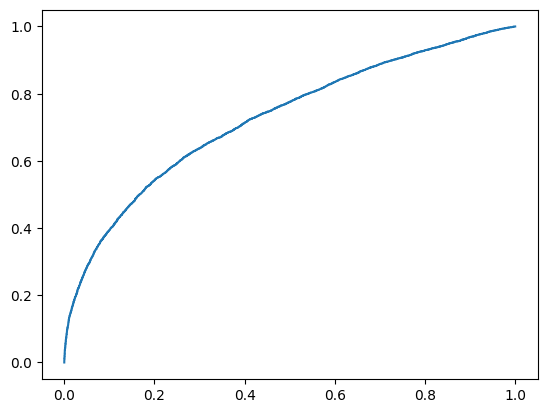

In [8]:
y_scores = model.predict_proba(X_val)[:,1]

fpr, tpr, thresholds = roc_curve(y_val, y_scores)

roc_auc = auc(fpr, tpr)

print(roc_auc)

plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)

In [9]:
importance = pd.Series(
    model.feature_importances_,
    index=X_train_model.columns
).sort_values(ascending=False)

print(importance.head(10))

customer_purchases_number    19.623723
recency_days                 12.412774
customer_revenue              5.903889
prod_comfort_wear_unknown     3.686480
prod_comfort_sole_unknown     2.680461
prod_type_1_boys              2.446493
prod_heel_encoded             2.194457
size_child                    1.932196
prod_material_leather         1.854468
prod_type_4_unknown           1.428982
dtype: float64


In [11]:
proba_train = model.predict_proba(X_train_split)[:,1]
proba_val = model.predict_proba(X_val)[:,1]
proba_test = model.predict_proba(X_test_model)[:,1]

X_train_split['prob_return'] = proba_train
X_val['prob_return'] = proba_val
X_test_model['prob_return'] = proba_test

In [15]:
reg_model = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    loss_function='MAE',
    verbose=200
)

In [ ]:

X_train_split, X_val, y_train_clf, y_val_clf = train_test_split(
    X_train_model,
    y_train,
    test_size=0.2,
    random_state=42
)

model.fit(X_train_split, y_train_clf)

X_train_split['prob_return'] = model.predict_proba(X_train_split)[:,1]
X_val['prob_return'] = model.predict_proba(X_val)[:,1]

y_train_reg = train_target.loc[X_train_split.index, 'revenue_2018_2019']
y_val_reg = train_target.loc[X_val.index, 'revenue_2018_2019']

reg_model.fit(X_train_split, y_train_reg)

0:	total: 59.4ms	remaining: 59.4s
200:	total: 10.8s	remaining: 43s
400:	total: 19.5s	remaining: 29.1s
600:	total: 30.5s	remaining: 20.2s
800:	total: 39.7s	remaining: 9.86s
999:	total: 48.6s	remaining: 0us
0:	learn: 69.9690159	total: 85.7ms	remaining: 1m 25s
200:	learn: 61.0639781	total: 12.9s	remaining: 51.5s
400:	learn: 60.9525048	total: 25.4s	remaining: 38s
600:	learn: 60.9506538	total: 40.8s	remaining: 27.1s
800:	learn: 60.9497909	total: 55.8s	remaining: 13.9s
999:	learn: 60.9493223	total: 1m 10s	remaining: 0us


CatBoostRegressor(depth=6, iterations=1000, learning_rate=0.03, loss_function='MAE', verbose=200)

In [28]:
preds = reg_model.predict(X_val)
mean_absolute_error(y_val_reg, preds)

CatBoostError: catboost/libs/data/model_dataset_compatibility.cpp:81: At position 0 should be feature with name customer_revenue (found n_orders).

In [19]:
corr, _ = spearmanr(y_val_reg, preds)
print(corr)

0.35568904374809646


In [1]:
# pipeline_submission.py
# VersiÃ³n limpia y lista para generar submission.csv
# - Construye features simples desde transactions
# - Genera feature "prob_return" via OOF (CatBoostClassifier)
# - Entrena regresor con target log1p(revenue) (CatBoostRegressor)
# - EvalÃºa MAE y Spearman en OOF y crea submission.csv

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
from catboost import CatBoostClassifier, CatBoostRegressor
import os

RANDOM_STATE = 42
NFOLDS = 5

# --- Ajusta rutas si hace falta ---


TRANS_PATH = "/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/transactions_2016_2017.csv"
TRAIN_PATH = "/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/customer_clv_train.csv"
TEST_PATH = "/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/customer_clv_test.csv"
OUTPUT_PATH = "/workspaces/Transactions-predictive-modeling-on-tabular-data-/data/submission.csv"

# --- Carga datos ---
print("Leyendo archivos...")
transactions = pd.read_csv(TRANS_PATH, parse_dates=["order_date", "pack_date"]) if os.path.exists(TRANS_PATH) else None
train_target = pd.read_csv(TRAIN_PATH) if os.path.exists(TRAIN_PATH) else None
test_customers = pd.read_csv(TEST_PATH) if os.path.exists(TEST_PATH) else None

if transactions is None or train_target is None or test_customers is None:
    raise FileNotFoundError("No se encuentran los archivos. AsegÃºrate que transactions_2016_2017.csv, customer_clv_train.csv y customer_clv_test.csv estÃ©n en el directorio.")

# --- Feature engineering (agregados simples por cliente) ---
print("Construyendo features a partir de transactions (agregados)...")
# Aseguramos que cust_id tenga el mismo tipo
transactions['cust_id'] = transactions['cust_id'].astype(str)

# Convertir sale_revenue a num (si hay strings)
transactions['sale_revenue'] = pd.to_numeric(transactions['sale_revenue'], errors='coerce').fillna(0.0)

# Fecha mÃ¡xima para calcular recencia (usar max global)
max_order_date = transactions['order_date'].max()

agg = transactions.groupby('cust_id').agg(
    n_orders=('sale_id', lambda x: x.nunique()),
    n_lines=('sale_revenue', 'count'),
    total_revenue=('sale_revenue', 'sum'),
    mean_revenue=('sale_revenue', 'mean'),
    last_order_date=('order_date', 'max'),
    first_order_date=('order_date', 'min'),
    n_products=('prod_id', lambda x: x.nunique()),
    mean_discount=('sale_discount_applied', lambda x: pd.to_numeric(x, errors='coerce').fillna(0).mean()),
    n_returned=('returned_to_shop_id', lambda x: x.notna().sum())
).reset_index()

# recencia en dÃ­as
agg['recency_days'] = (max_order_date - agg['last_order_date']).dt.days
agg['customer_lifespan_days'] = (agg['last_order_date'] - agg['first_order_date']).dt.days

# rellenar nulos y crear features sencillas
for c in ['n_orders','n_lines','total_revenue','mean_revenue','n_products','mean_discount','n_returned','recency_days','customer_lifespan_days']:
    agg[c] = agg[c].fillna(0)

# Frecuencias de brand como ejemplo (top 20)
if 'prod_brand' in transactions.columns:
    top_brands = transactions['prod_brand'].value_counts().nlargest(20).index.tolist()
    brand_counts = (transactions[transactions['prod_brand'].isin(top_brands)]
                    .groupby(['cust_id','prod_brand'])['prod_brand'].count()
                    .unstack(fill_value=0))
    brand_counts.columns = [f'brand_{str(c)}' for c in brand_counts.columns]
    agg = agg.merge(brand_counts.reset_index(), on='cust_id', how='left')
    agg.fillna(0, inplace=True)

# NormalizaciÃ³n simple
agg['avg_revenue_per_order'] = agg['total_revenue'] / (agg['n_orders'].replace(0, np.nan))
agg['avg_revenue_per_order'] = agg['avg_revenue_per_order'].fillna(0)

# Preparar X_train y X_test
print("Uniendo features con train/test...")
train_target['cust_id'] = train_target['cust_id'].astype(str)
test_customers['cust_id'] = test_customers['cust_id'].astype(str)

X_all = pd.concat([
    train_target[['cust_id']],
    test_customers[['cust_id']]
], ignore_index=True)

X_all = X_all.merge(agg, on='cust_id', how='left')
# rellenar clientes sin historial con ceros
X_all.fillna(0, inplace=True)

# Split de nuevo
X_train = X_all[X_all['cust_id'].isin(train_target['cust_id'].astype(str))].copy()
X_test = X_all[X_all['cust_id'].isin(test_customers['cust_id'].astype(str))].copy()

# Targets
train_target = train_target.set_index(train_target['cust_id'].astype(str))

y_reg = train_target.loc[X_train['cust_id'].astype(str), 'revenue_2018_2019'].values
# binario para el clasificador: si gastÃ³ algo en target period
y_bin = (y_reg > 0).astype(int)

# Features a usar (excluir cust_id y fechas)
drop_cols = ['cust_id', 'last_order_date', 'first_order_date']
features = [c for c in X_train.columns if c not in drop_cols]

X_train_feat = X_train[features].reset_index(drop=True)
X_test_feat = X_test[features].reset_index(drop=True)

# --- OOF para generar prob_return ---
print("Generando feature prob_return (OOF) con StratifiedKFold)")
skf = StratifiedKFold(n_splits=NFOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_probs = np.zeros(len(X_train_feat))
test_probs = np.zeros(len(X_test_feat))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_feat, y_bin)):
    print(f"Fold {fold+1}/{NFOLDS}")
    X_tr, X_val = X_train_feat.iloc[tr_idx], X_train_feat.iloc[val_idx]
    y_tr, y_val = y_bin[tr_idx], y_bin[val_idx]

    clf = CatBoostClassifier(
        iterations=100,
        depth=6,
        learning_rate=0.03,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=RANDOM_STATE,
        verbose=100
    )

    clf.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=False)

    oof_probs[val_idx] = clf.predict_proba(X_val)[:, 1]
    test_probs += clf.predict_proba(X_test_feat)[:, 1] / NFOLDS

# adjuntar la feature
X_train_feat['prob_return'] = oof_probs
X_test_feat['prob_return'] = test_probs

# --- RegresiÃ³n con CV (log1p target) ---
print("Entrenando regresores en K-Fold (objetivo: log1p(revenue))")
kf = KFold(n_splits=NFOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds_reg = np.zeros(len(X_train_feat))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_feat)):
    print(f"Reg Fold {fold+1}/{NFOLDS}")
    X_tr, X_val = X_train_feat.iloc[tr_idx], X_train_feat.iloc[val_idx]
    y_tr = np.log1p(y_reg[tr_idx])
    y_val = np.log1p(y_reg[val_idx])

    reg = CatBoostRegressor(
        iterations=100,
        depth=6,
        learning_rate=0.03,
        loss_function='MAE',
        random_seed=RANDOM_STATE,
        verbose=100
    )

    reg.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=False)

    preds_val_log = reg.predict(X_val)
    oof_preds_reg[val_idx] = preds_val_log
    

# convertir OOF a escala original
oof_preds_original = np.expm1(oof_preds_reg)
oof_preds_original[oof_preds_original < 1e-3] = 0

# evaluaciÃ³n
mae_oof = mean_absolute_error(y_reg, oof_preds_original)
spearman_oof, _ = spearmanr(y_reg, oof_preds_original)
print(f"OOF MAE: {mae_oof:.6f}")
print(f"OOF Spearman: {spearman_oof:.6f}")

# --- Entrenar final sobre todo y predecir test ---
print("Entrenando modelo final sobre todo el train...")
reg_final = CatBoostRegressor(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    loss_function='MAE',
    random_seed=RANDOM_STATE,
    verbose=100
)

reg_final.fit(X_train_feat, np.log1p(y_reg), use_best_model=False)

preds_test_log = reg_final.predict(X_test_feat)
preds_test = np.expm1(preds_test_log)
# Limpieza numérica
preds_test[preds_test < 1e-3] = 0
# asegurar no negativos
preds_test = np.clip(preds_test, 0, None)


# crear submission
submission = pd.DataFrame({
    'cust_id': X_test['cust_id'].values,
    'revenue_2018_2019': preds_test
})

submission.to_csv(OUTPUT_PATH, index=False)
print(f"Submission guardada en {OUTPUT_PATH}")

# Mostrar resumen
print('\nResumen:')
print(f'OOF MAE: {mae_oof:.4f}')
print(f'OOF Spearman: {spearman_oof:.4f}')
print(f'Submission rows: {len(submission)}')


Leyendo archivos...


/tmp/ipykernel_65371/2812294094.py:29: DtypeWarning: Columns (0: prod_size) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv(TRANS_PATH, parse_dates=["order_date", "pack_date"]) if os.path.exists(TRANS_PATH) else None


Construyendo features a partir de transactions (agregados)...
Uniendo features con train/test...
Generando feature prob_return (OOF) con StratifiedKFold)
Fold 1/5
0:	test: 0.6999018	best: 0.6999018 (0)	total: 77.8ms	remaining: 7.7s
99:	test: 0.7189559	best: 0.7189559 (99)	total: 3.94s	remaining: 0us

bestTest = 0.7189558919
bestIteration = 99

Fold 2/5
0:	test: 0.6953530	best: 0.6953530 (0)	total: 20.5ms	remaining: 2.03s
99:	test: 0.7149045	best: 0.7149045 (99)	total: 2.83s	remaining: 0us

bestTest = 0.7149044647
bestIteration = 99

Fold 3/5
0:	test: 0.6993572	best: 0.6993572 (0)	total: 23ms	remaining: 2.28s
99:	test: 0.7169248	best: 0.7169248 (99)	total: 2.59s	remaining: 0us

bestTest = 0.7169247985
bestIteration = 99

Fold 4/5
0:	test: 0.7027973	best: 0.7027973 (0)	total: 32.4ms	remaining: 3.21s
99:	test: 0.7196788	best: 0.7196788 (99)	total: 2.56s	remaining: 0us

bestTest = 0.7196787553
bestIteration = 99

Fold 5/5
0:	test: 0.7031923	best: 0.7031923 (0)	total: 23.1ms	remaining: 2.29